# Population Separation

The goal of this is to take what we've done in the Michelson work, and push it further to seperate the model population of the sonora-bobcat and Dr. Pope data. We'll be using the MIRI filters we used previously, but also tack on additional filters to see what other separation we can get. 

In [61]:
%load_ext autoreload
%autoreload 2

import numpy as np
from dwarfhunt import planets as helpers
from dwarfhunt import galaxies as galaxy_helpers
from dwarfhunt import plots as ccp
from dwarfhunt.gmm import GMMClassifier, balanced_accuracy, fit_and_score
from species.read.read_model import ReadModel
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import dwarfhunt
from dwarfhunt import paths

randomSeed = 2

db = dwarfhunt.init(force_species_init=True)

# Target filters to base all data off of

TARGET_FILTERS = ("JWST/MIRI.F1065C", "JWST/MIRI.F1140C", "JWST/MIRI.F1550C", "WISE/WISE.W3")

# Short column labels ("F1065C", ...), derived rather than retyped so adding a
# filter above is the only edit needed. helpers.filter_label is the same function
# the planet and galaxy helpers use to name their own columns, so these are
# guaranteed to match the keys on both sides.
FILTER_LABELS = [helpers.filter_label(name) for name in TARGET_FILTERS]

# n filters give C(n, 2) pairwise colors but only n-1 INDEPENDENT ones. Colors are
# differences, so they are blind to overall brightness, and that lost direction
# costs exactly one dimension. Every remaining pair is then a sum of these -- e.g.
# (F1065C - F1550C) == (F1065C - F1140C) + (F1140C - F1550C), exactly, not
# approximately. Feeding all C(n, 2) to a full-covariance GMM makes every
# component covariance singular; sklearn's reg_covar=1e-6 papers over that
# silently, so the fit still returns and BIC still prints, but both are
# meaningless. Adjacent pairs are one independent basis and discard nothing:
# every dropped color is reconstructible from these.
COLOR_NAMES = [f"{blue} - {red}" for blue, red in zip(FILTER_LABELS, FILTER_LABELS[1:])]


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
species

Version: 0.10.4
Working folder: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/pop-separation

Configuration file: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/species_config.ini
Database file: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/data/species_database.hdf5
Data folder: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/data

Configuration settings:
   - Database: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/data/species_database.hdf5
   - Data folder: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/data
   - Magnitude of Vega: 0.03

Multiprocessing: mpi4py not installed


## Load Model Information

This section of code can be run to bring in all of the model data you need. If you already have it downloaded, you won't need to run this code section. 

In [62]:
db.add_model('sonora-bobcat', wavel_range=(0.61, 19.0), wavel_sampling=1000.0)


-------------------------
Add grid of model spectra
-------------------------

Database tag: sonora-bobcat
Model name: Sonora Bobcat

Unpacking 1131/1131 model spectra from Sonora Bobcat (392 MB)... [DONE]

Please cite Marley et al. (2021) when using Sonora Bobcat in a publication
Reference URL: https://zenodo.org/record/5063476

Wavelength range (um) = 0.61 - 19.0
Sampling (lambda/d_lambda) = 1000.0
Teff range (K) = 200 - 2400

Adding Sonora Bobcat model spectra... /Users/mitchellfoote/Documents/Source/research/dwarfhunt/data/sonora-bobcat/sonora-bobcat_teff_950_logg_5.50_feh_0.5_spec.npy  

Grid points stored in the database:
   - Teff = [ 200.  225.  250.  275.  300.  325.  350.  375.  400.  425.  450.  475.
  500.  525.  550.  575.  600.  650.  700.  750.  800.  850.  900.  950.
 1000. 1100. 1200. 1300. 1400. 1500. 1600. 1700. 1800. 1900. 2000. 2100.
 2200. 2300. 2400.]
   - log(g) = [3.   3.25 3.5  3.75 4.   4.25 4.5  4.75 5.   5.25 5.5 ]
   - [Fe/H] = [-0.5  0.   0.5]

Number of

/opt/homebrew/Caskroom/miniconda/base/envs/dwarfhunt/lib/python3.11/site-packages/species/util/data_util.py:413: RuntimeWarning: divide by zero encountered in log10
  flux = np.log10(flux)


## Load planet and galaxy data

Now we need to make sure we add the correctly seeded (correctly meaning that we don't need to redo our exp new every time). 

In [63]:
bobcat_model = ReadModel('sonora-bobcat')
bobcat_planets = helpers.generate_planet_arrays(bobcat_model, radius_range=(0.6, 1.3), distance=10, num_samples=800, rng=randomSeed)

bobcat_planets = helpers.update_planet_flux_and_magnitude(bobcat_model, bobcat_planets, TARGET_FILTERS)
bobcat_planets = helpers.add_color_columns(bobcat_planets, FILTER_LABELS)
# Pass COLOR_NAMES explicitly: the default is "every 'A - B' key present", which
# would hand back all C(n, 2) pairwise colors and also leave the column order at
# the mercy of dict insertion order.
names, colors = helpers.color_color_matrix(bobcat_planets, COLOR_NAMES)

# AGN fraction of each template, in the same order as all_galaxy_data below --
# this is what lets the "which galaxies fail" cell split failures by template
# without re-hardcoding the three files a second time.
GALAXY_AGN_FRACTIONS = (0.0, 0.5, 1.0)

AGN_00_data = galaxy_helpers.galaxy_color_color_data_k15(paths.galaxy_template('K15_templates/MIR_library/MIR0.0.txt'), filter_names=TARGET_FILTERS)
AGN_05_data = galaxy_helpers.galaxy_color_color_data_k15(paths.galaxy_template('K15_templates/MIR_library/MIR0.5.txt'), filter_names=TARGET_FILTERS)
AGN_10_data = galaxy_helpers.galaxy_color_color_data_k15(paths.galaxy_template('K15_templates/MIR_library/MIR1.0.txt'), filter_names=TARGET_FILTERS)

all_galaxy_data = [AGN_00_data, AGN_05_data, AGN_10_data]

# Drive the loop off the resolved column list, not len(TARGET_FILTERS). Those two
# agree only at n=3 (C(3, 2) == 3), which is why this read correctly in
# michelson-gmm-exploration.ipynb and silently truncated here.
total_colors_len = len(names)

all_planet_color_data = []
all_galaxy_color_data = []

for i in range(total_colors_len):
    planet_colors = colors[:, i]
    # Galaxy rows stack in AGN-fraction order 0.0, 0.5, 1.0 -- the same order for
    # every color, so a row index means the same object in every column of X.
    galaxy_color_data = np.concatenate([g[names[i]] for g in all_galaxy_data])
    all_planet_color_data.append(planet_colors)
    all_galaxy_color_data.append(galaxy_color_data)

color_data_pairs = []
for i in range(len(all_planet_color_data)):
    all_certain_color = np.concatenate((all_planet_color_data[i], all_galaxy_color_data[i]))
    color_data_pairs.append(all_certain_color)

X = np.column_stack(color_data_pairs)
Y = np.concatenate((np.zeros(len(all_planet_color_data[0])), np.ones(len(all_galaxy_color_data[0]))))

DWARF_CLASS, GALAXY_CLASS = 0.0, 1.0
CLASS_LABELS = {DWARF_CLASS: "brown dwarf", GALAXY_CLASS: "galaxy"}

# Planets occupy rows 0 .. n_planets-1 of X, galaxies the rest. Everything that
# traces a row of X back to the object that made it keys off this one number.
n_planets = len(all_planet_color_data[0])

# Per-galaxy metadata in that same stacked row order, so galaxy row r of X came
# from all_g_redshift[r - n_planets] at AGN fraction all_g_agn_frac[r - n_planets].
all_g_redshift = np.concatenate([g["redshift"] for g in all_galaxy_data])
all_g_agn_frac = np.concatenate([
    np.full(len(g["redshift"]), frac)
    for g, frac in zip(all_galaxy_data, GALAXY_AGN_FRACTIONS)
])

print(f"colors used ({len(names)}): {names}")
print(f"X: {X.shape}   planets: {int((Y == 0).sum())}   galaxies: {int((Y == 1).sum())}")

# Guard the whole point of choosing an independent basis: if this ever prints a
# rank below X.shape[1], some column is a combination of the others and every GMM
# covariance downstream is singular.
print(f"rank(X): {np.linalg.matrix_rank(X)} of {X.shape[1]} columns")

# Carry the original row indices through the split, so a misclassified test point
# can be traced back to its T_eff (dwarfs) or redshift/AGN fraction (galaxies).
idx = np.arange(len(X))
X_train, X_test, Y_train, Y_test, idx_train, idx_test = train_test_split(
    X, Y, idx, stratify=Y, random_state=0)


colors used (3): ['F1065C - F1140C', 'F1140C - F1550C', 'F1550C - W3']
X: (1070, 3)   planets: 800   galaxies: 270
rank(X): 3 of 3 columns


## Let's verify the BIC

As with the GMM exploration, we're going to verify the BIC to make sure we use the correct number of components.

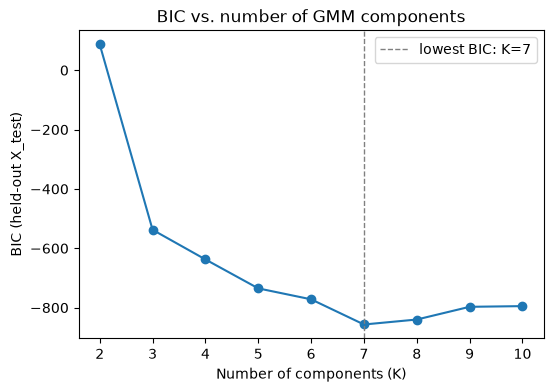

K= 2  BIC=  86.6155
K= 3  BIC=-537.7319
K= 4  BIC=-637.5211
K= 5  BIC=-735.0395
K= 6  BIC=-771.8907
K= 7  BIC=-856.7145  <-- lowest BIC
K= 8  BIC=-839.9722
K= 9  BIC=-797.1176
K=10  BIC=-794.8014


In [64]:
K_candidates = range(2, 11)
bic_scores = []
for k in K_candidates:
    candidate = GMMClassifier(n_components=k, random_state=0).fit(X_train, Y_train)
    bic_scores.append(candidate.bic(X_test))

best_k = K_candidates[int(np.argmin(bic_scores))]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(K_candidates), bic_scores, marker="o")
ax.axvline(best_k, color="0.5", linestyle="--", linewidth=1,
           label=f"lowest BIC: K={best_k}")
ax.set_xlabel("Number of components (K)")
ax.set_ylabel("BIC (held-out X_test)")
ax.set_title("BIC vs. number of GMM components")
ax.legend()
plt.show()

for k, bic_val in zip(K_candidates, bic_scores):
    flag = "  <-- lowest BIC" if k == best_k else ""
    print(f"K={k:2d}  BIC={bic_val:9.4f}{flag}")

## Moving forward

Pick the K, and let's make a matrix. For seed 2, we're going to use K = 7

BIC: -856.7145
Balanced accuracy score: 0.9853


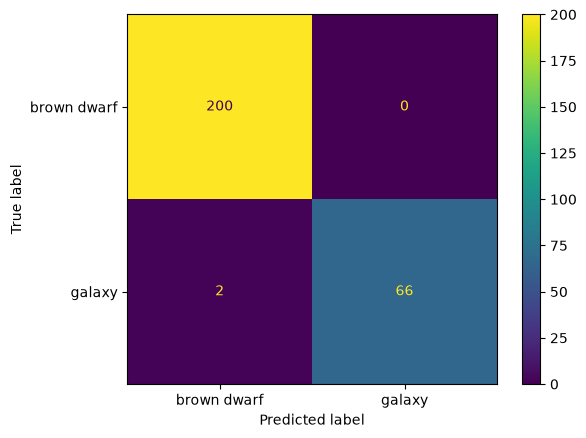

In [65]:
K = best_k

clf = GMMClassifier(n_components=K, random_state=0).fit(X_train, Y_train)
pred_best = clf.predict(X_test)
score = clf.score(X_test, Y_test)

matrix = ConfusionMatrixDisplay.from_predictions(
    Y_test, pred_best, display_labels=["brown dwarf", "galaxy"]
)

bic = clf.bic(X_test)
print(f"BIC: {bic:.4f}")
print(f"Balanced accuracy score: {score:.4f}")

### Component Comp
We want to double check the components we have to flag any irrigularities

In [66]:
import pandas as pd

table = pd.DataFrame(clf.component_table(X_train, Y_train)).sort_values("margin")
table

,component,assigned_class,weight,margin,degenerate,mass_class_0.0,n_class_0.0,mass_class_1.0,n_class_1.0
1,1,0.0,0.114975,0.119857,False,1.460605e-01,86,2.620335e-02,5
6,6,0.0,0.117345,0.152130,False,1.555328e-01,96,3.403036e-03,1
4,4,0.0,0.136486,0.176937,False,1.810978e-01,110,4.161116e-03,1
2,2,0.0,0.163959,0.218153,False,2.181533e-01,129,1.028629e-19,0
0,0,0.0,0.222087,0.296757,False,2.967571e-01,179,7.135331e-63,0
3,3,1.0,0.090729,0.359912,False,2.513456e-32,0,3.599122e-01,73
5,5,1.0,0.154419,0.603922,False,2.398536e-03,0,6.063203e-01,122


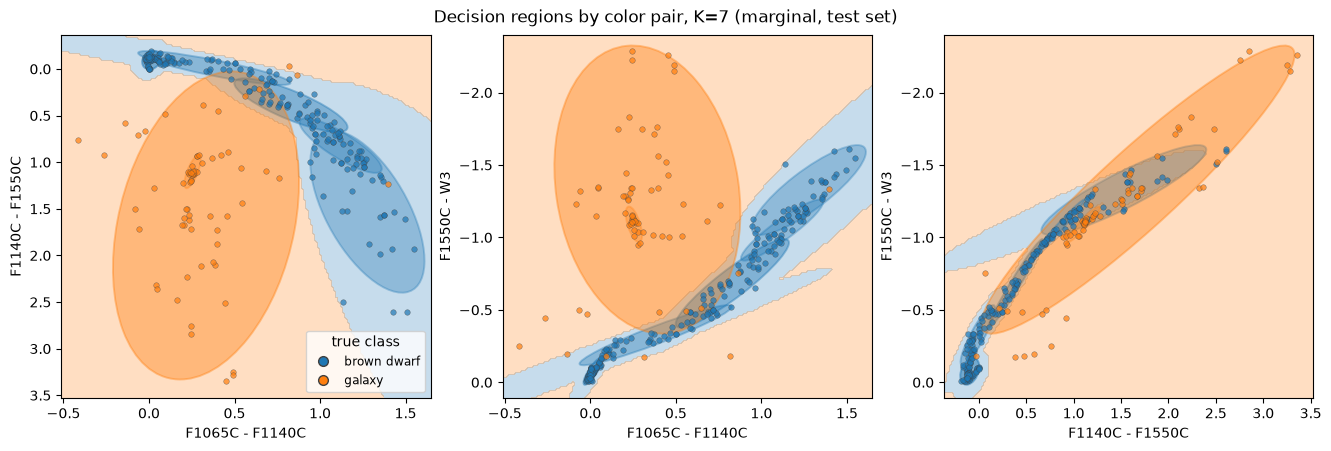

In [67]:
# One panel per pair of color axes. With d colors there are C(d, 2) planes and no
# reason to privilege one, so draw them all -- 3 colors gives 3 panels.
#
# mode="marginal" integrates the off-panel colors out under the fitted mixture:
# each panel answers "what would this classifier decide knowing only these two
# colors?". That is a projection, not a cross-section, so two classes that look
# tangled in one panel may be cleanly split by the color that panel isn't
# showing. Compare against mode="slice" (next cell) before reading too much into
# any single panel.
class_colors = ccp.class_color_map(clf.classes_)

fig, axes, pairs = ccp.plot_decision_grid(
    clf, X_test, Y_test, names,
    mode="marginal",
    class_colors=class_colors,
    class_labels=CLASS_LABELS,
    suptitle=f"Decision regions by color pair, K={K} (marginal, test set)")
plt.show()


### The same planes, as a slice instead of a projection

A 2-D panel cannot show a 3-D decision boundary, so there are two different
honest pictures and they answer different questions. Drawing both is the check
that neither is misleading you.

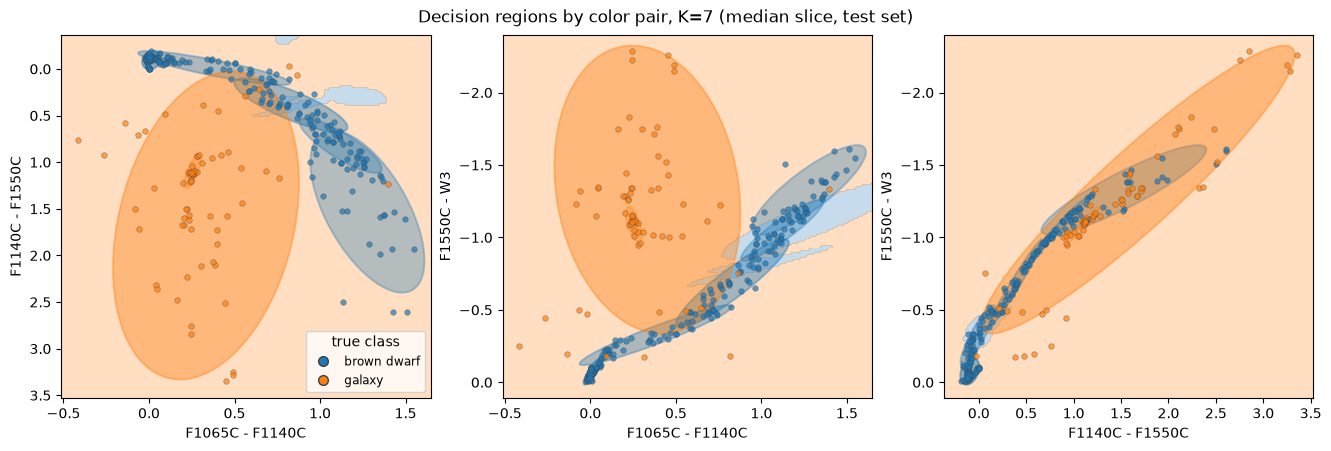

In [68]:
# The same planes as a genuine cross-section: hold the off-panel colors fixed at
# their median and evaluate the real d-dimensional classifier there. Unlike the
# marginal figure this IS a slice of the true boundary -- but only of that one
# cut, and most of the plotted points do not lie on it.
#
# Panels that disagree between the two figures are the interesting ones: there,
# the off-panel color is doing real classification work.
fig, axes, pairs = ccp.plot_decision_grid(
    clf, X_test, Y_test, names,
    mode="slice",
    class_colors=class_colors,
    class_labels=CLASS_LABELS,
    suptitle=f"Decision regions by color pair, K={K} (median slice, test set)")
plt.show()


## Which dwarfs fail

Trace the misclassified test-set dwarfs back to `bobcat_planets` via `idx_test`
and look at where they sit in T_eff -- do failures cluster at one end of the
sequence, or spread evenly? One projection panel per color pair, since a dwarf
that looks lost in one plane may be well separated in another.

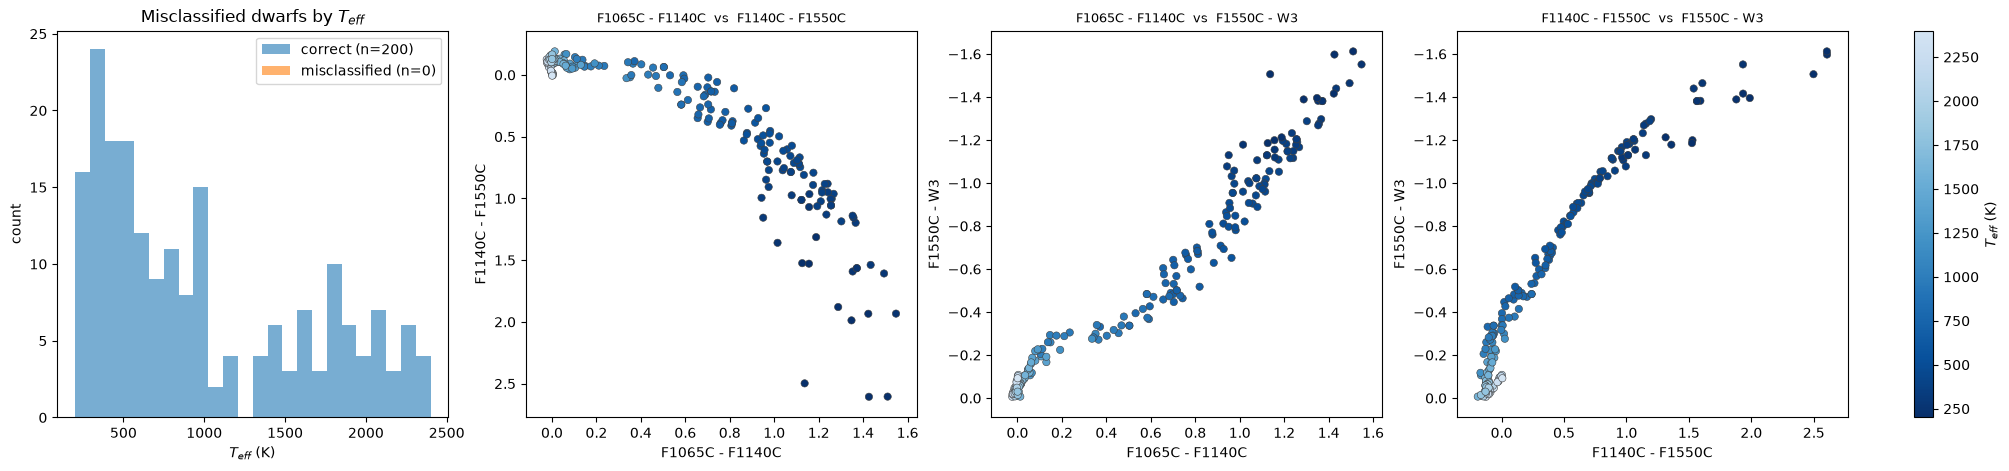

0 / 200 test-set dwarfs misclassified as galaxy


In [69]:
from matplotlib.colors import Normalize

# Metadata aligned to X_test's rows. A test row is a dwarf exactly when its
# original index lands below n_planets; galaxy rows keep nan and are dropped by
# the cls= mask inside plot_failures, never reaching a scatter call.
dwarf_rows = idx_test < n_planets
teff_test = np.full(len(idx_test), np.nan)
teff_test[dwarf_rows] = bobcat_planets["teff"][idx_test[dwarf_rows]]
assert np.array_equal(dwarf_rows, Y_test == DWARF_CLASS)

is_dwarf = Y_test == DWARF_CLASS
wrong = is_dwarf & (pred_best != DWARF_CLASS)

pairs = ccp.feature_pairs(X.shape[1])
n_panels = 1 + len(pairs)
ncols = min(4, n_panels)
nrows = int(np.ceil(n_panels / ncols))
# layout="constrained" measures the long y labels ("F1140C - F1550C") and the
# spanning colorbar before placing the axes, so labels stop bleeding into the
# panel to their left. Set at creation -- a later tight_layout() cannot handle a
# colorbar attached to several axes at once.
fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 4.6 * nrows),
                         squeeze=False, layout="constrained")
axes = axes.ravel()

bins = np.linspace(np.nanmin(teff_test), np.nanmax(teff_test), 25)
axes[0].hist(teff_test[is_dwarf & (pred_best == DWARF_CLASS)], bins=bins,
             alpha=0.6, label=f"correct (n={int((is_dwarf & (pred_best == DWARF_CLASS)).sum())})")
axes[0].hist(teff_test[wrong], bins=bins, alpha=0.6,
             label=f"misclassified (n={int(wrong.sum())})")
axes[0].set_xlabel("$T_{eff}$ (K)")
axes[0].set_ylabel("count")
axes[0].legend()
axes[0].set_title("Misclassified dwarfs by $T_{eff}$")

# One shared Normalize across every panel, so a given blue means the same
# temperature no matter which color pair you are looking at.
norm = Normalize(vmin=np.nanmin(teff_test), vmax=np.nanmax(teff_test))

for ax, pair in zip(axes[1:], pairs):
    handle, n_wrong, n_total = ccp.plot_failures(
        ax, X_test, Y_test, pred_best, cls=DWARF_CLASS, dims=pair,
        c=teff_test, cmap=ccp.DWARF_CMAP, norm=norm)
    ccp.style_panel(ax, names[pair[0]], names[pair[1]])
    ax.set_title(f"{names[pair[0]]}  vs  {names[pair[1]]}", fontsize=9)

for ax in axes[n_panels:]:
    ax.set_visible(False)

fig.colorbar(handle, ax=axes[1:n_panels].tolist(), label="$T_{eff}$ (K)")
plt.show()

print(f"{int(wrong.sum())} / {int(is_dwarf.sum())} test-set dwarfs misclassified as galaxy")


## Which galaxies fail

The galaxy-side counterpart. Galaxies have no T_eff, but they do have the axes
their tracks are built along: redshift, plus which K15 AGN-fraction template they
came from. Both are recovered from `idx_test` through the same `n_planets` offset
the setup cell defined, so this no longer depends on the old `all_g_color_1`
variables.

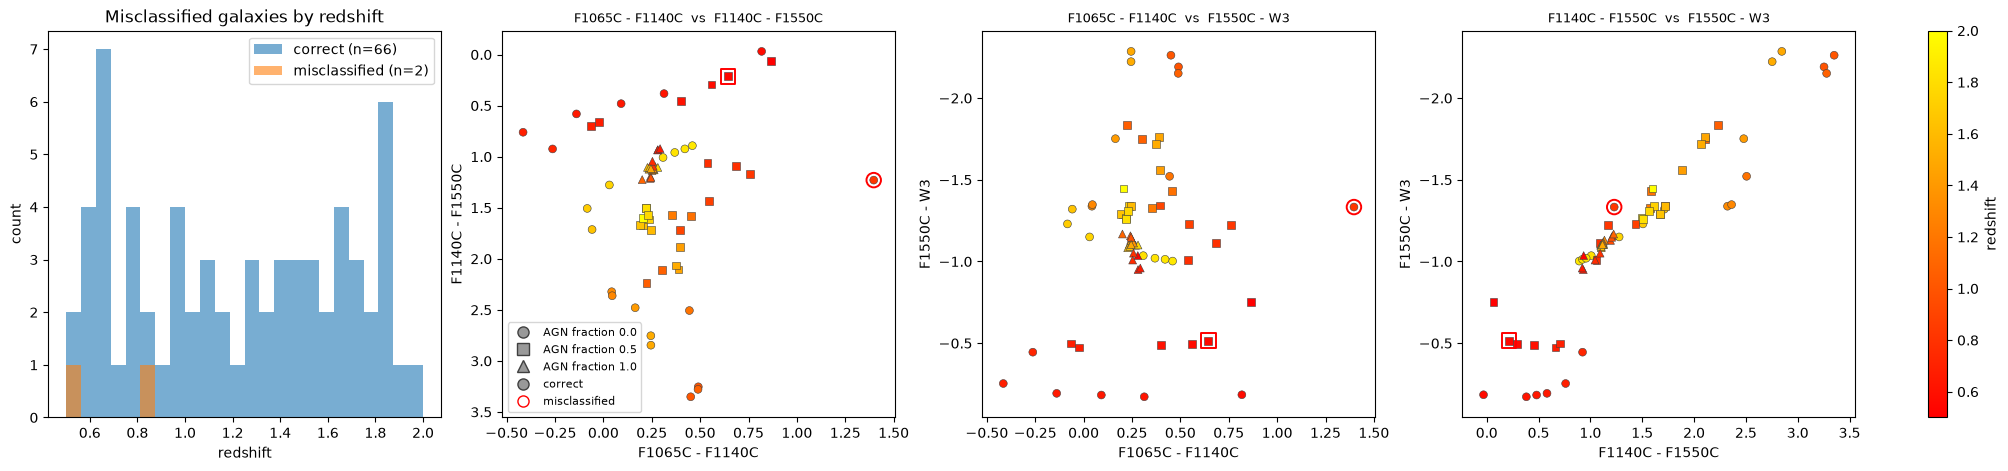

2 / 68 test-set galaxies misclassified as brown dwarf
AGN fraction 0.0: 1 / 23 misclassified
AGN fraction 0.5: 1 / 26 misclassified
AGN fraction 1.0: 0 / 19 misclassified


In [70]:
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

# Galaxy-side metadata aligned to X_test's rows, via the same offset rule.
galaxy_rows = idx_test >= n_planets
z_test = np.full(len(idx_test), np.nan)
agn_test = np.full(len(idx_test), np.nan)
z_test[galaxy_rows] = all_g_redshift[idx_test[galaxy_rows] - n_planets]
agn_test[galaxy_rows] = all_g_agn_frac[idx_test[galaxy_rows] - n_planets]
assert np.array_equal(galaxy_rows, Y_test == GALAXY_CLASS)

is_galaxy = Y_test == GALAXY_CLASS
wrong = is_galaxy & (pred_best != GALAXY_CLASS)

pairs = ccp.feature_pairs(X.shape[1])
n_panels = 1 + len(pairs)
ncols = min(4, n_panels)
nrows = int(np.ceil(n_panels / ncols))
# layout="constrained" measures the long y labels ("F1140C - F1550C") and the
# spanning colorbar before placing the axes, so labels stop bleeding into the
# panel to their left. Set at creation -- a later tight_layout() cannot handle a
# colorbar attached to several axes at once.
fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 4.6 * nrows),
                         squeeze=False, layout="constrained")
axes = axes.ravel()

bins = np.linspace(np.nanmin(z_test), np.nanmax(z_test), 25)
axes[0].hist(z_test[is_galaxy & (pred_best == GALAXY_CLASS)], bins=bins,
             alpha=0.6, label=f"correct (n={int((is_galaxy & (pred_best == GALAXY_CLASS)).sum())})")
axes[0].hist(z_test[wrong], bins=bins, alpha=0.6,
             label=f"misclassified (n={int(wrong.sum())})")
axes[0].set_xlabel("redshift")
axes[0].set_ylabel("count")
axes[0].legend()
axes[0].set_title("Misclassified galaxies by redshift")

# AGN fraction is categorical, so it gets marker shape rather than fighting
# redshift for the color scale. All markers share one Normalize so the colorbar
# means the same thing for every shape -- and one marker per template means this
# adapts if GALAXY_AGN_FRACTIONS grows.
markers = ["o", "s", "^", "D", "v", "P"]
agn_markers = {frac: markers[i % len(markers)]
               for i, frac in enumerate(GALAXY_AGN_FRACTIONS)}
norm = Normalize(vmin=np.nanmin(z_test), vmax=np.nanmax(z_test))

for ax, pair in zip(axes[1:], pairs):
    for frac, marker in agn_markers.items():
        handle, _, _ = ccp.plot_failures(
            ax, X_test, Y_test, pred_best, cls=GALAXY_CLASS, dims=pair,
            c=z_test, cmap=ccp.GALAXY_CMAP, norm=norm, marker=marker, size=32,
            subset=agn_test == frac)
    ccp.style_panel(ax, names[pair[0]], names[pair[1]])
    ax.set_title(f"{names[pair[0]]}  vs  {names[pair[1]]}", fontsize=9)

shape_handles = [Line2D([], [], marker=marker, linestyle="none", markerfacecolor="0.6",
                        markeredgecolor="0.25", markersize=8, label=f"AGN fraction {frac}")
                 for frac, marker in agn_markers.items()]
status_handles = [
    Line2D([], [], marker="o", linestyle="none", markerfacecolor="0.6",
           markeredgecolor="0.25", markersize=8, label="correct"),
    Line2D([], [], marker="o", linestyle="none", markerfacecolor="none",
           markeredgecolor="red", markersize=8, label="misclassified"),
]
axes[1].legend(handles=shape_handles + status_handles, fontsize=8, loc="best")

for ax in axes[n_panels:]:
    ax.set_visible(False)

fig.colorbar(handle, ax=axes[1:n_panels].tolist(), label="redshift")
plt.show()

print(f"{int(wrong.sum())} / {int(is_galaxy.sum())} test-set galaxies misclassified as brown dwarf")
for frac in GALAXY_AGN_FRACTIONS:
    n_total = int(np.sum(agn_test == frac))
    n_wrong = int(np.sum((agn_test == frac) & wrong))
    print(f"AGN fraction {frac}: {n_wrong} / {n_total} misclassified")


## Does the extra color actually help?

This cell is meant to determine if adding additional color values actuall improve the balanced accuracy, and how much headroom we gain for each additional color value. We're going to do a refit across the same 20 train/test splits. During this sequence, we're going to recalcuate K, so that it doesn't confound the model, and we get the best value coming out of as we can. That way we remove the extra confounding variable. 

This will output multiple values to view:

**The balanced accuracy +- standard deviation.** This is the basic balanced accuracy vs std that we've been using in other places in the project. 

**The paired difference.** We want to be able to determine that the extra color helped overall, not just particular sets that were nicer to the model. So we compare them based on the same split, which makes it a better comparison. Splits vary in difficulty, and that variation is shared by every color set tested on them. Subtracting within a split removes that difficulty, so what's left is the effect of the color itself. The variance reported is sem not std, as we want to answer "is the improvement real", and not "how much does a split wobble."

**The win count.** We want an actual improvment count, which is more convincing than a mean, and it doesn't assume the differences are normal.

**The K distribution.** If we land on the same K often, then we're finding actual structure. If we get a wide range, then we're hitting a lot of noise and not adding a ton of value. 

In [71]:
K_CANDIDATES = list(range(2, 11))
N_SEEDS = 20
TEST_SIZE = 0.4

# Nested prefixes of the color list. Color i is FILTER_LABELS[i] -
# FILTER_LABELS[i+1], so a prefix of length m spans FILTER_LABELS[:m+1] and each
# step adds exactly one filter and one independent color.
COLOR_SET_SIZES = list(range(2, X.shape[1] + 1))

results = {}
for m in COLOR_SET_SIZES:
    cols = list(range(m))
    scores = np.empty(N_SEEDS)
    chosen_k = np.empty(N_SEEDS, dtype=int)

    for seed in range(N_SEEDS):
        Xtr, Xte, ytr, yte = train_test_split(
            X[:, cols], Y, test_size=TEST_SIZE, stratify=Y, random_state=seed)

        # GMM random_state pinned so only the split varies from seed to seed.
        fits = [GMMClassifier(n_components=k, random_state=0).fit(Xtr, ytr)
                for k in K_CANDIDATES]
        best = int(np.argmin([f.bic(Xtr) for f in fits]))

        chosen_k[seed] = K_CANDIDATES[best]
        scores[seed] = fits[best].score(Xte, yte)

    results[m] = {"scores": scores, "k": chosen_k}
    print(f"{m} colors ({', '.join(FILTER_LABELS[:m + 1])}) done")

print(f"\n{'colors':<8}{'filters':<36}{'bal. acc (mean +- std)':<28}{'K median [min-max]'}")
for m in COLOR_SET_SIZES:
    s, k = results[m]["scores"], results[m]["k"]
    acc = f"{s.mean():.4f} +- {s.std(ddof=1):.4f}"
    print(f"{m:<8}{' '.join(FILTER_LABELS[:m + 1]):<36}{acc:<28}"
          f"{int(np.median(k))} [{k.min()}-{k.max()}]")

# Paired against the smallest color set, on the same splits.
base_m = COLOR_SET_SIZES[0]
print(f"\nPaired against {base_m} colors, same {N_SEEDS} splits:")
for m in COLOR_SET_SIZES[1:]:
    d = results[m]["scores"] - results[base_m]["scores"]
    wins = int((d > 0).sum())
    ties = int((d == 0).sum())
    print(f"  +{m - base_m} color: mean diff {d.mean():+.4f} "
          f"+- {d.std(ddof=1) / np.sqrt(N_SEEDS):.4f} (sem of the difference), "
          f"better on {wins}/{N_SEEDS} splits, tied on {ties}")

# Headroom fraction: we want to see how much of the remaining error is removed by adding a color, not just the absolute gain. 
# 1 - err_new / err_base, with err = 1 - balanced accuracy.
#
# As a note, we're excluding splits where the baseline is already perfect, because those won't have headroom, which will make the ratio undefined. 
# Those splits are counted and reported, but not included in the mean.

print(f"\nHeadroom closed vs {base_m} colors (share of remaining balanced error removed):")
base_scores = results[base_m]["scores"]
for m in COLOR_SET_SIZES[1:]:
    new_scores = results[m]["scores"]
    headroom = 1.0 - base_scores
    usable = headroom > 0

    err_base = 1.0 - base_scores.mean()
    err_new = 1.0 - new_scores.mean()
    pooled = 1.0 - err_new / err_base if err_base > 0 else float("nan")

    if usable.sum() > 1:
        frac = (new_scores[usable] - base_scores[usable]) / headroom[usable]
        sem = frac.std(ddof=1) / np.sqrt(len(frac))
        per_split = (f"{100 * frac.mean():+.1f}% +- {100 * sem:.1f}% "
                     f"(per split, n={int(usable.sum())})")
    elif usable.sum() == 1:
        frac = (new_scores[usable] - base_scores[usable]) / headroom[usable]
        per_split = f"{100 * frac.mean():+.1f}% (only 1 usable split, no spread)"
    else:
        per_split = "undefined -- baseline is perfect on every split"

    print(f"  +{m - base_m} color: {per_split}")
    print(f"{'':>13}pooled from means {100 * pooled:+.1f}%   "
          f"balanced error {err_base:.4f} -> {err_new:.4f}")
    if not usable.all():
        print(f"{'':>13}{int((~usable).sum())} split(s) excluded: baseline already perfect")


print("\nSelected K per color set:")
for m in COLOR_SET_SIZES:
    vals, counts = np.unique(results[m]["k"], return_counts=True)
    spread = ", ".join(f"K={v}: {c}" for v, c in zip(vals, counts))
    print(f"  {m} colors -> {spread}")


2 colors (F1065C, F1140C, F1550C) done
3 colors (F1065C, F1140C, F1550C, W3) done

colors  filters                             bal. acc (mean +- std)      K median [min-max]
2       F1065C F1140C F1550C                0.9574 +- 0.0142            9 [7-10]
3       F1065C F1140C F1550C W3             0.9809 +- 0.0070            9 [8-10]

Paired against 2 colors, same 20 splits:
  +1 color: mean diff +0.0236 +- 0.0033 (sem of the difference), better on 19/20 splits, tied on 0

Headroom closed vs 2 colors (share of remaining balanced error removed):
  +1 color: +51.1% +- 4.8% (per split, n=20)
             pooled from means +55.3%   balanced error 0.0426 -> 0.0191

Selected K per color set:
  2 colors -> K=7: 1, K=8: 3, K=9: 8, K=10: 8
  3 colors -> K=8: 2, K=9: 8, K=10: 10
